In [3]:
import os
repo = 'boston-marathons'
counter = 0
max_depth = 50
current = os.getcwd()
while True:
    current_tmp = os.path.basename(os.getcwd())
    if current_tmp == repo:
        print(f"Main dir found: {os.getcwd()}")
        break
    else:
        os.chdir("..")
        counter += 1
        if counter >= max_depth:
            print(f"Reached {max_depth} levels up — '{repo}' not found.")
            os.chdir(current)
            print(f"Current path: {current}")
            break

Main dir found: D:\Scripts\Data Science\projekty\repo\boston-marathons


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math as math
from scripts.mappings import continent_colors

In [6]:
df = pd.read_csv('data/clean/boston_features.csv')
df.head()

,Name,M/F,Age,Age Group,Country,Continent,City,Pace,5K,10K,15K,20K,25K,30K,35K,40K,Official Time,Year,Place_Year,Place_Global
0,"Desisa, Lelisa",M,25,22–25,ETH,Africa,Ambo,3.065431,0.245278,0.495278,0.749167,1.008056,1.268611,1.533333,1.799722,2.044167,2.154722,2015,1,1
1,"Kirui, Geoffrey",M,24,22–25,KEN,Africa,Keringet,3.075787,0.256944,0.507778,0.762222,1.020833,1.283056,1.550278,1.805278,2.048056,2.160278,2017,1,2
2,"Tsegay, Yemane Adhane",M,30,30–33,ETH,Africa,Addis Ababa,3.086144,0.245278,0.495278,0.749444,1.007778,1.268611,1.533056,1.799722,2.045000,2.163333,2015,2,3
3,"Rupp, Galen",M,30,30–33,USA,North America,Portland,3.086144,0.256667,0.507500,0.762222,1.020833,1.283056,1.550278,1.805278,2.053889,2.166111,2017,2,4
4,"Chebet, Wilson",M,29,26–29,KEN,Africa,Marakwet,3.096500,0.245278,0.495278,0.749167,1.008056,1.268611,1.533333,1.799722,2.050278,2.172778,2015,3,5


In [8]:
plt.style.use('seaborn-v0_8-whitegrid')

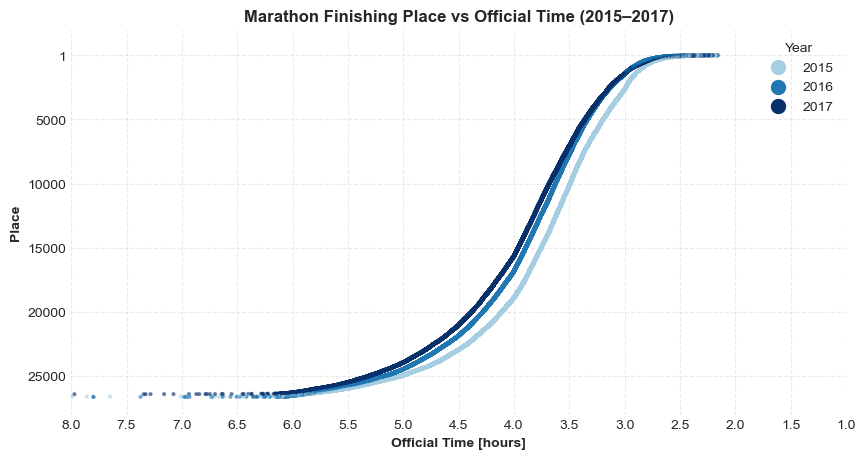

In [145]:
color_year = {
    2015: '#a6cee3',  # jasny
    2016: '#1f78b4',  # średni
    2017: '#08306b',  # ciemny
}

# subset
subset = df[['Official Time', 'Place_Year', 'Year']]
subset = subset.sort_values(by='Official Time')

# ax
fig, ax = plt.subplots(figsize=(10,5))

## plot 
# settings
x = subset['Official Time']
y = subset['Place_Year']
colors = subset['Year'].map(color_year)
# create
ax.scatter(x, y, color=colors, s=4, alpha=0.5)

## ax settings
# x
ax.set_xlabel('Official Time [hours]', weight='bold')
ax.set_xlim(1,8)
ax.set_xticks(np.arange(1,8.5,0.5))
ax.invert_xaxis()
# y
ax.set_ylabel('Place', weight='bold')
ax.set_ylim(-2000,28000)
yticks = np.arange(0,27001,5000)
yticks[0] = 1
ax.set_yticks(yticks)
ax.invert_yaxis()

## style
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_title('Marathon Finishing Place vs Official Time (2015–2017)', weight='bold')
# legend
for year, color in color_year.items():
    ax.scatter([], [], color=color, label=year, s=100)
ax.legend(title='Year', loc='upper right', bbox_to_anchor=(1,1))
# spines
spines = ["top", "bottom", "left", "right"]
for spine in spines:
    ax.spines[spine].set_visible(False)

# plt.savefig("test/chart_3.png", dpi=300, bbox_inches='tight')
plt.show()

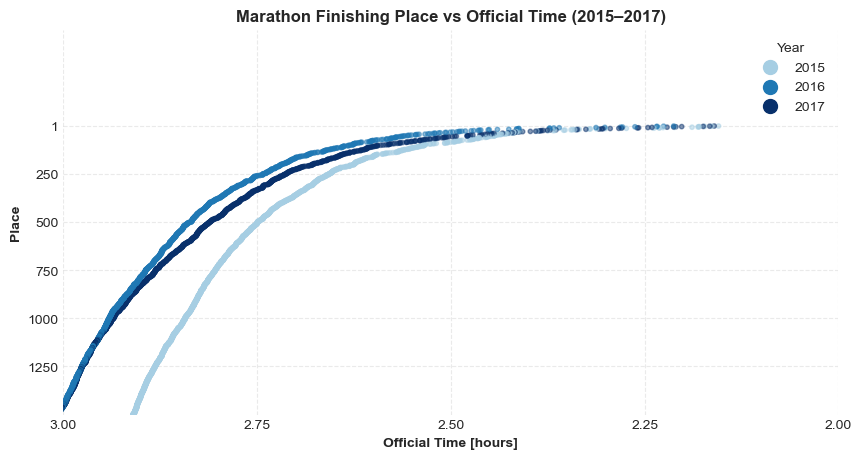

In [203]:
color_year = {
    2015: '#a6cee3',  # jasny
    2016: '#1f78b4',  # średni
    2017: '#08306b',  # ciemny
}

# subset
subset = df[['Official Time', 'Place_Year', 'Year']]
subset = subset.sort_values(by='Official Time')

# ax
fig, ax = plt.subplots(figsize=(10,5))

## plot 
# settings
x = subset['Official Time']
y = subset['Place_Year']
colors = subset['Year'].map(color_year)
# create
ax.scatter(x, y, color=colors, s=10, alpha=0.5)

## ax settings
# x
ax.set_xlabel('Official Time [hours]', weight='bold')
ax.set_xlim(2,3)
ax.set_xticks(np.arange(2,3.1,0.25))
ax.invert_xaxis()
# y
ax.set_ylabel('Place', weight='bold')
ax.set_ylim(-500,1500)
yticks = np.arange(0,1251,250)
yticks[0] = 1
ax.set_yticks(yticks)
ax.invert_yaxis()

## style
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_title('Marathon Finishing Place vs Official Time (2015–2017)', weight='bold')
# legend
for year, color in color_year.items():
    ax.scatter([], [], color=color, label=year, s=100)
ax.legend(title='Year', loc='upper right', bbox_to_anchor=(1,1))
# spines
spines = ["top", "bottom", "left", "right"]
for spine in spines:
    ax.spines[spine].set_visible(False)

# plt.savefig("test/chart_3_zoom.png", dpi=300, bbox_inches='tight')
plt.show()